# Análise dos Experimentos — WebKB 10-fold CV

Pasta de resultados: `results/webkb-10cv-20260504-145448-f5ee59`

**Modos analisados:**
- `baseline` — treino direto sem currículo e sem IS
- `is` — treino com Instance Selection (IS), sem currículo
- `cl` — treino com Curriculum Learning (CL), sem IS
- `is_cl` — treino com IS + CL combinados

Intervalo de confiança: **95%** (bootstrap t-distribution)

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

RESULTS_DIR = Path('results/mpqa-10cv-20260511-142747-7939ac')
MODES = ['baseline', 'is', 'cl', 'is_cl']
N_FOLDS = 10
CI_ALPHA = 0.05  # 95% CI

MODE_LABELS = {
    'baseline': 'Baseline',
    'is': 'IS',
    'cl': 'CL',
    'is_cl': 'IS + CL',
}
MODE_COLORS = {
    'baseline': '#4C72B0',
    'is':       '#DD8452',
    'cl':       '#55A868',
    'is_cl':    '#C44E52',
}

def ci95(values):
    """95% confidence interval via t-distribution."""
    n = len(values)
    if n < 2:
        return (np.nan, np.nan)
    m = np.mean(values)
    se = stats.sem(values)
    h = se * stats.t.ppf(1 - CI_ALPHA / 2, df=n - 1)
    return (m - h, m + h)

print('Setup concluído.')

Setup concluído.


## 1. Carregamento dos dados e verificação de completude

In [2]:
timings_rows = []
phase_metrics_rows = []
train_history_rows = []
completeness = {m: [] for m in MODES}  # fold -> status

EXPECTED_PHASES = {
    'baseline': {'full'},
    'is':       {'full'},
    'cl':       {'clean', 'diverse', 'hard'},
    'is_cl':    {'clean', 'diverse', 'hard'},
}

for mode in MODES:
    for fold in range(N_FOLDS):
        fold_dir = RESULTS_DIR / f'{mode}_fold{fold}'
        status = 'ok'

        # --- timings ---
        t_file = fold_dir / 'timings.csv'
        if t_file.exists():
            t = pd.read_csv(t_file, index_col='name')['seconds'].to_dict()
            t.update({'mode': mode, 'fold': fold})
            timings_rows.append(t)
        else:
            status = 'sem timings'

        # --- phase_metrics ---
        pm_file = fold_dir / 'phase_metrics.csv'
        if pm_file.exists():
            pm = pd.read_csv(pm_file)
            pm['mode'] = mode
            pm['fold'] = fold
            phase_metrics_rows.append(pm)
            # Check completeness
            observed = set(pm['phase'].unique())
            expected = EXPECTED_PHASES[mode]
            if not expected.issubset(observed):
                status = f'incompleto (fases: {sorted(observed)})'
        else:
            status = 'sem phase_metrics'

        # --- train_history ---
        th_file = fold_dir / 'train_history.csv'
        if th_file.exists():
            th = pd.read_csv(th_file)
            th['mode'] = mode
            th['fold'] = fold
            train_history_rows.append(th)

        completeness[mode].append({'fold': fold, 'status': status})

df_timings = pd.DataFrame(timings_rows)
df_pm      = pd.concat(phase_metrics_rows, ignore_index=True)
df_th      = pd.concat(train_history_rows, ignore_index=True)

print(f'Timings carregados: {len(df_timings)} entradas')
print(f'Phase metrics: {len(df_pm)} linhas')
print(f'Train history: {len(df_th)} linhas')

Timings carregados: 40 entradas
Phase metrics: 80 linhas
Train history: 71340 linhas


### 1.1 Experimentos incompletos por modo

In [3]:
summary_rows = []
for mode in MODES:
    ok     = sum(1 for x in completeness[mode] if x['status'] == 'ok')
    failed = N_FOLDS - ok
    failed_folds = [x['fold'] for x in completeness[mode] if x['status'] != 'ok']
    failed_reasons = [x['status'] for x in completeness[mode] if x['status'] != 'ok']
    summary_rows.append({
        'Modo': MODE_LABELS[mode],
        'Completos': ok,
        'Incompletos': failed,
        'Folds com falha': str(failed_folds) if failed_folds else '—',
        'Motivo': failed_reasons[0] if failed_reasons else '—',
    })

df_completeness = pd.DataFrame(summary_rows).set_index('Modo')
print('Resumo de completude dos experimentos (10 folds por modo):\n')
display(df_completeness)

# Detail
print('\nDetalhe por fold:')
for mode in MODES:
    issues = [(x['fold'], x['status']) for x in completeness[mode] if x['status'] != 'ok']
    if issues:
        for fold, reason in issues:
            print(f'  [{MODE_LABELS[mode]}] fold {fold}: {reason}')

Resumo de completude dos experimentos (10 folds por modo):



,Completos,Incompletos,Folds com falha,Motivo
Modo,,,,
Baseline,10,0,—,—
IS,10,0,—,—
CL,10,0,—,—
IS + CL,10,0,—,—



Detalhe por fold:


## 2. Análise dos tempos de treinamento

> **Nota:** Para modos CL e IS+CL, são incluídos apenas os folds completos (todas as fases concluídas).

In [4]:
# Folds completos por modo
complete_folds = {}
for mode in MODES:
    complete_folds[mode] = [x['fold'] for x in completeness[mode] if x['status'] == 'ok']

def get_timing_values(df_timings, mode, col):
    sub = df_timings[(df_timings['mode'] == mode) & (df_timings['fold'].isin(complete_folds[mode]))]
    return sub[col].dropna().values

def describe_series(values, label):
    lo, hi = ci95(values)
    return {
        'Modo': label,
        'n': len(values),
        'Média (s)': np.mean(values),
        'Mediana (s)': np.median(values),
        'Std (s)': np.std(values, ddof=1),
        'Min (s)': np.min(values),
        'Max (s)': np.max(values),
        'IC95% inferior': lo,
        'IC95% superior': hi,
    }

# Collect data
train_times  = {m: get_timing_values(df_timings, m, 'model_train_time_s') for m in MODES}
total_times  = {m: get_timing_values(df_timings, m, 'total_run_time_s')   for m in MODES}

print('Dados de tempo coletados.')
for m in MODES:
    print(f'  {MODE_LABELS[m]}: {len(train_times[m])} folds completos')

Dados de tempo coletados.
  Baseline: 10 folds completos
  IS: 10 folds completos
  CL: 10 folds completos
  IS + CL: 10 folds completos


### 2.1 Tempo de treinamento do modelo (`model_train_time_s`)

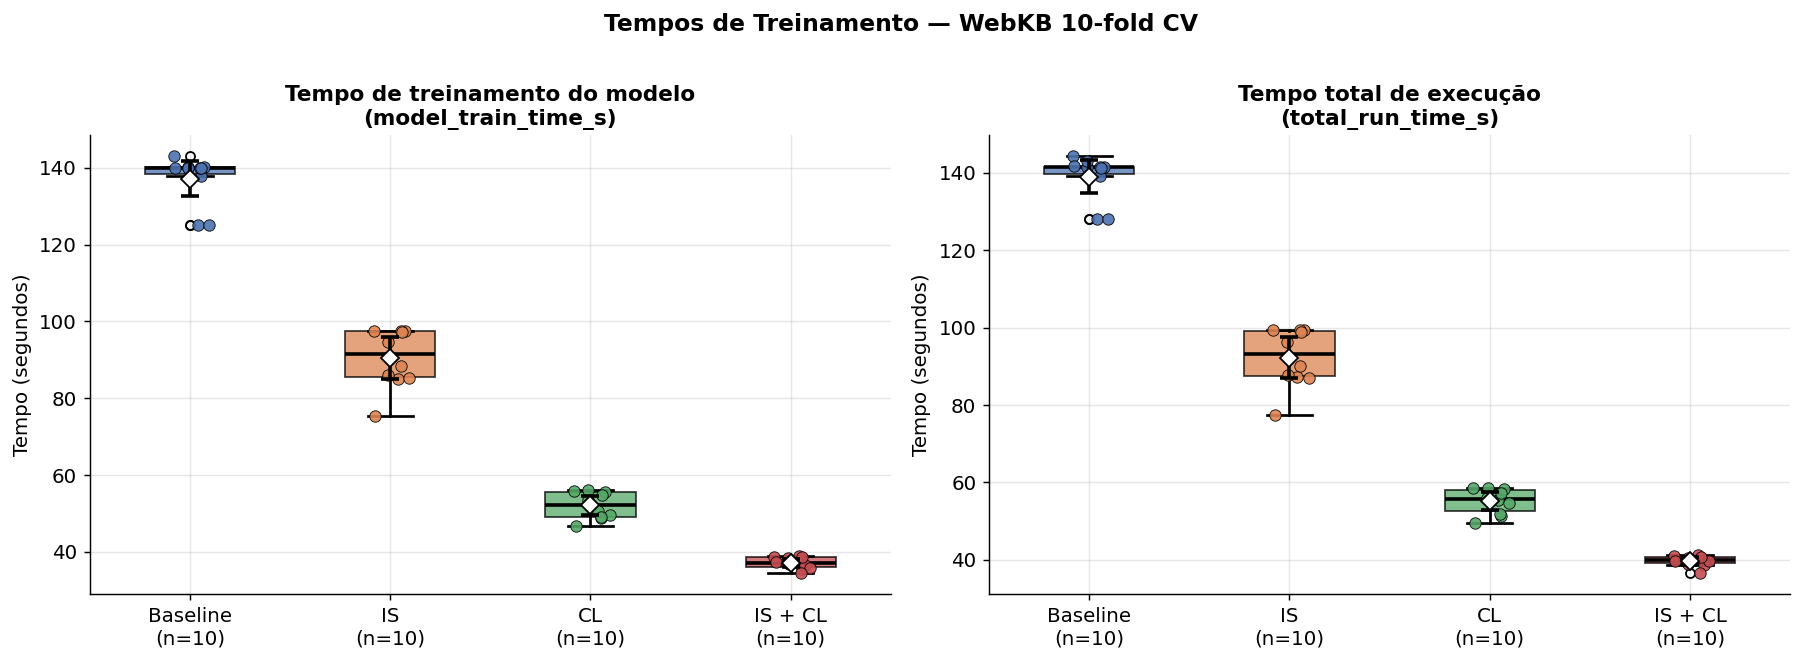

Diamante = média  |  Barra = IC 95%  |  Pontos = folds individuais


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (times_dict, title, col) in zip(axes, [
    (train_times, 'Tempo de treinamento do modelo\n(model_train_time_s)', 'model_train_time_s'),
    (total_times, 'Tempo total de execução\n(total_run_time_s)', 'total_run_time_s'),
]):
    data   = [times_dict[m] for m in MODES]
    labels = [f"{MODE_LABELS[m]}\n(n={len(times_dict[m])})" for m in MODES]
    colors = [MODE_COLORS[m] for m in MODES]

    bp = ax.boxplot(
        data, labels=labels, patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=5),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Overlay individual points
    for i, (vals, color) in enumerate(zip(data, colors), start=1):
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, edgecolor='black', linewidth=0.5,
                   zorder=5, s=40, alpha=0.9)

    # CI error bars for the mean
    for i, (m, vals) in enumerate(zip(MODES, data), start=1):
        if len(vals) >= 2:
            lo, hi = ci95(vals)
            mean   = np.mean(vals)
            ax.errorbar(i, mean, yerr=[[mean - lo], [hi - mean]],
                        fmt='D', color='white', ecolor='black',
                        elinewidth=2, capsize=5, capthick=2,
                        markersize=7, zorder=10, markeredgecolor='black')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Tempo (segundos)')

plt.suptitle('Tempos de Treinamento — WebKB 10-fold CV', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Diamante = média  |  Barra = IC 95%  |  Pontos = folds individuais')

### 2.2 Estatísticas descritivas dos tempos

In [6]:
print('=== TEMPO DE TREINAMENTO DO MODELO (model_train_time_s) ===')
rows = [describe_series(train_times[m], MODE_LABELS[m]) for m in MODES]
df_train_desc = pd.DataFrame(rows).set_index('Modo')
display(df_train_desc.round(2))

print('\n=== TEMPO TOTAL DE EXECUÇÃO (total_run_time_s) ===')
rows = [describe_series(total_times[m], MODE_LABELS[m]) for m in MODES]
df_total_desc = pd.DataFrame(rows).set_index('Modo')
display(df_total_desc.round(2))

=== TEMPO DE TREINAMENTO DO MODELO (model_train_time_s) ===


,n,Média (s),Mediana (s),Std (s),Min (s),Max (s),IC95% inferior,IC95% superior
Modo,,,,,,,,
Baseline,10,137.16,140.03,6.44,125.13,143.01,132.55,141.76
IS,10,90.45,91.45,7.60,75.42,97.62,85.01,95.89
CL,10,52.08,52.14,3.48,46.71,56.05,49.59,54.57
IS + CL,10,37.11,37.08,1.54,34.36,38.79,36.01,38.22



=== TEMPO TOTAL DE EXECUÇÃO (total_run_time_s) ===


,n,Média (s),Mediana (s),Std (s),Min (s),Max (s),IC95% inferior,IC95% superior
Modo,,,,,,,,
Baseline,10,138.99,141.45,5.85,128.16,144.27,134.81,143.18
IS,10,92.27,93.17,7.51,77.44,99.39,86.90,97.64
CL,10,55.18,55.73,3.26,49.60,58.66,52.85,57.51
IS + CL,10,39.71,40.05,1.40,36.47,41.19,38.71,40.71


### 2.3 Decomposição do tempo total (stacked bar)

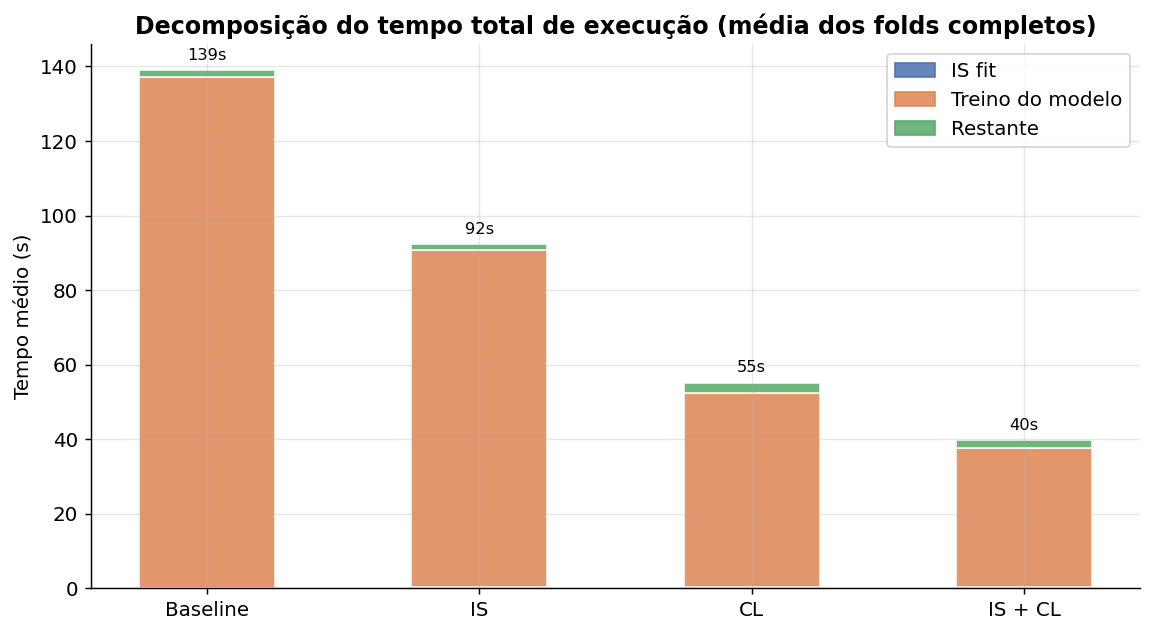

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

def _mean_or_zero(sub_df, col):
    """Média segura: coluna ausente ou só NaN → 0 (evita barras invisíveis no stacked bar)."""
    if col not in sub_df.columns:
        return 0.0
    m = sub_df[col].mean()
    return 0.0 if pd.isna(m) else float(m)

comp_colors = ['#4C72B0', '#DD8452', '#55A868']
comp_labels = ['IS fit', 'Treino do modelo', 'Restante']

x = np.arange(len(MODES))
width = 0.5

for idx, mode in enumerate(MODES):
    sub = df_timings[(df_timings['mode'] == mode) & (df_timings['fold'].isin(complete_folds[mode]))]
    total_mean = float(sub['total_run_time_s'].mean())

    is_fit  = _mean_or_zero(sub, 'is_fit_time_s')
    train_t = _mean_or_zero(sub, 'model_train_time_s')
    rest    = max(0.0, total_mean - is_fit - train_t)

    bottom = 0.0
    for val, color in zip([is_fit, train_t, rest], comp_colors):
        ax.bar(idx, val, width, bottom=bottom, color=color, alpha=0.85, edgecolor='white')
        bottom += val

    ax.text(idx, total_mean + 2, f'{total_mean:.0f}s', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([MODE_LABELS[m] for m in MODES])
ax.set_ylabel('Tempo médio (s)')
ax.set_title('Decomposição do tempo total de execução (média dos folds completos)',
             fontweight='bold')
patches = [mpatches.Patch(color=c, label=l, alpha=0.85)
           for c, l in zip(comp_colors, comp_labels)]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.show()


## 3. Histórico de perda por época

In [8]:
# Compute per-epoch mean loss  (group by mode, fold, phase, epoch)
df_epoch = (
    df_th
    .groupby(['mode', 'fold', 'phase', 'epoch'])['loss']
    .mean()
    .reset_index()
    .rename(columns={'loss': 'mean_loss'})
)

# For CL modes, we build a global 'training step' index:
#   encode phase order as an offset to the epoch so phases appear in sequence
PHASE_ORDER = {'full': 0, 'clean': 0, 'diverse': 1, 'hard': 2}
PHASE_EPOCHS = {}  # will be filled below

def build_global_epoch(sub):
    """Assign a monotonically increasing global epoch across phases."""
    sub = sub.copy().sort_values(['phase', 'epoch'])
    offset = 0
    rows = []
    for ph in sorted(sub['phase'].unique(), key=lambda p: PHASE_ORDER.get(p, 99)):
        ph_df = sub[sub['phase'] == ph].copy()
        ph_df['global_epoch'] = ph_df['epoch'] + offset
        offset = ph_df['global_epoch'].max()
        rows.append(ph_df)
    return pd.concat(rows)

# Apply per fold
parts = []
for (mode, fold), grp in df_epoch.groupby(['mode', 'fold']):
    parts.append(build_global_epoch(grp))
df_epoch_global = pd.concat(parts, ignore_index=True)

print('Histórico de perda por época preparado.')
print(df_epoch_global.head())

Histórico de perda por época preparado.
       mode  fold phase  epoch  mean_loss  global_epoch
0  baseline     0  full      1   0.437485             1
1  baseline     0  full      2   0.272813             2
2  baseline     0  full      3   0.213982             3
3  baseline     0  full      4   0.174803             4
4  baseline     0  full      5   0.149386             5


### 3.1 Loss médio por época — todos os modos com IC 95%

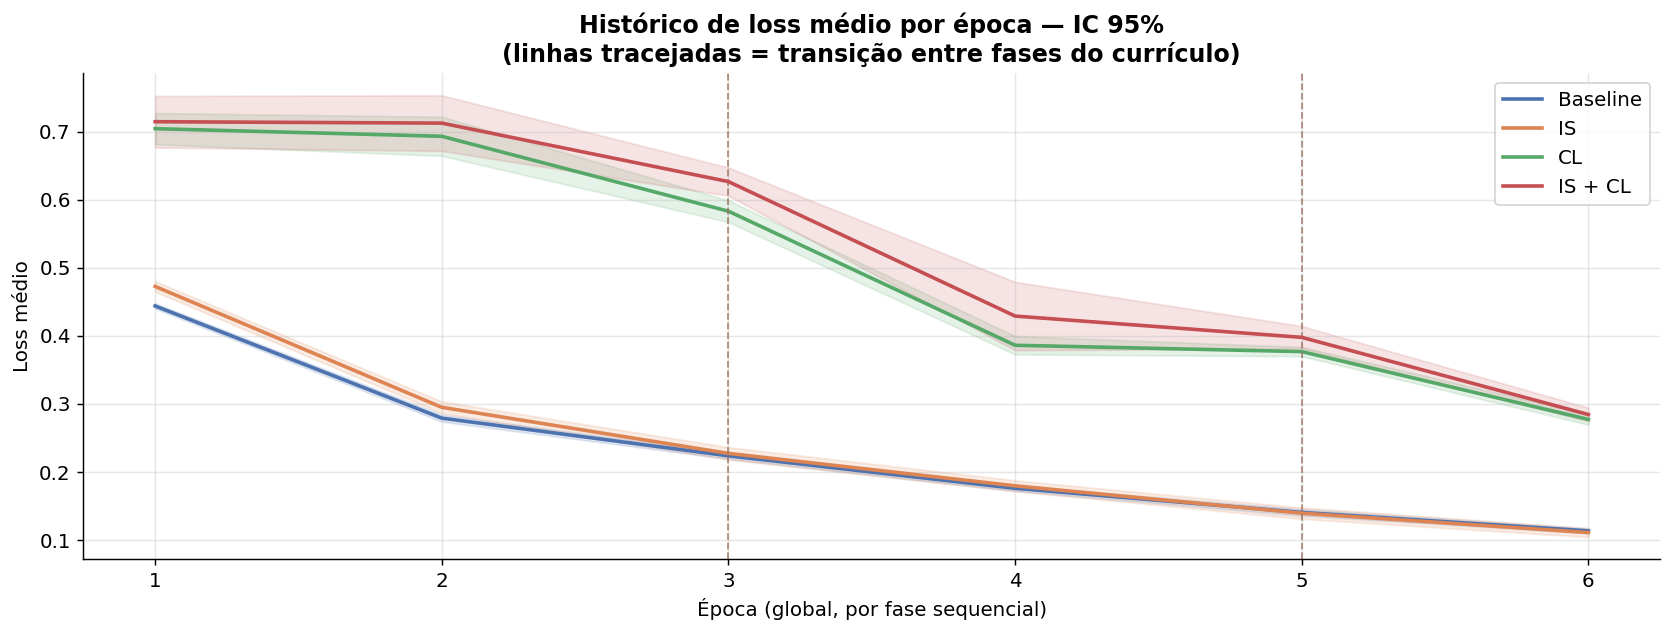

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

for mode in MODES:
    sub = df_epoch_global[
        (df_epoch_global['mode'] == mode) &
        (df_epoch_global['fold'].isin(complete_folds[mode]))
    ]
    if sub.empty:
        continue

    agg = sub.groupby('global_epoch')['mean_loss'].agg(['mean', 'std', 'count'])
    agg = agg[agg['count'] >= 2].copy()
    agg['se']   = agg['std'] / np.sqrt(agg['count'])
    agg['t']    = stats.t.ppf(1 - CI_ALPHA / 2, df=agg['count'] - 1)
    agg['lo']   = agg['mean'] - agg['t'] * agg['se']
    agg['hi']   = agg['mean'] + agg['t'] * agg['se']

    epochs = agg.index.values
    color  = MODE_COLORS[mode]
    ax.plot(epochs, agg['mean'], label=MODE_LABELS[mode], color=color, linewidth=2)
    ax.fill_between(epochs, agg['lo'], agg['hi'], color=color, alpha=0.15)

    # Mark phase transitions for CL modes
    if mode in ('cl', 'is_cl'):
        sub_fold0 = sub[sub['fold'] == complete_folds[mode][0]]
        for ph in ['diverse', 'hard']:
            ph_start = sub_fold0[sub_fold0['phase'] == ph]['global_epoch'].min()
            if not np.isnan(ph_start):
                ax.axvline(ph_start, color=color, linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Época (global, por fase sequencial)')
ax.set_ylabel('Loss médio')
ax.set_title('Histórico de loss médio por época — IC 95%\n'
             '(linhas tracejadas = transição entre fases do currículo)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Acurácia ao final de cada fase de currículo

Como a acurácia só é registrada ao final de cada fase, apresentamos sua evolução entre as fases.

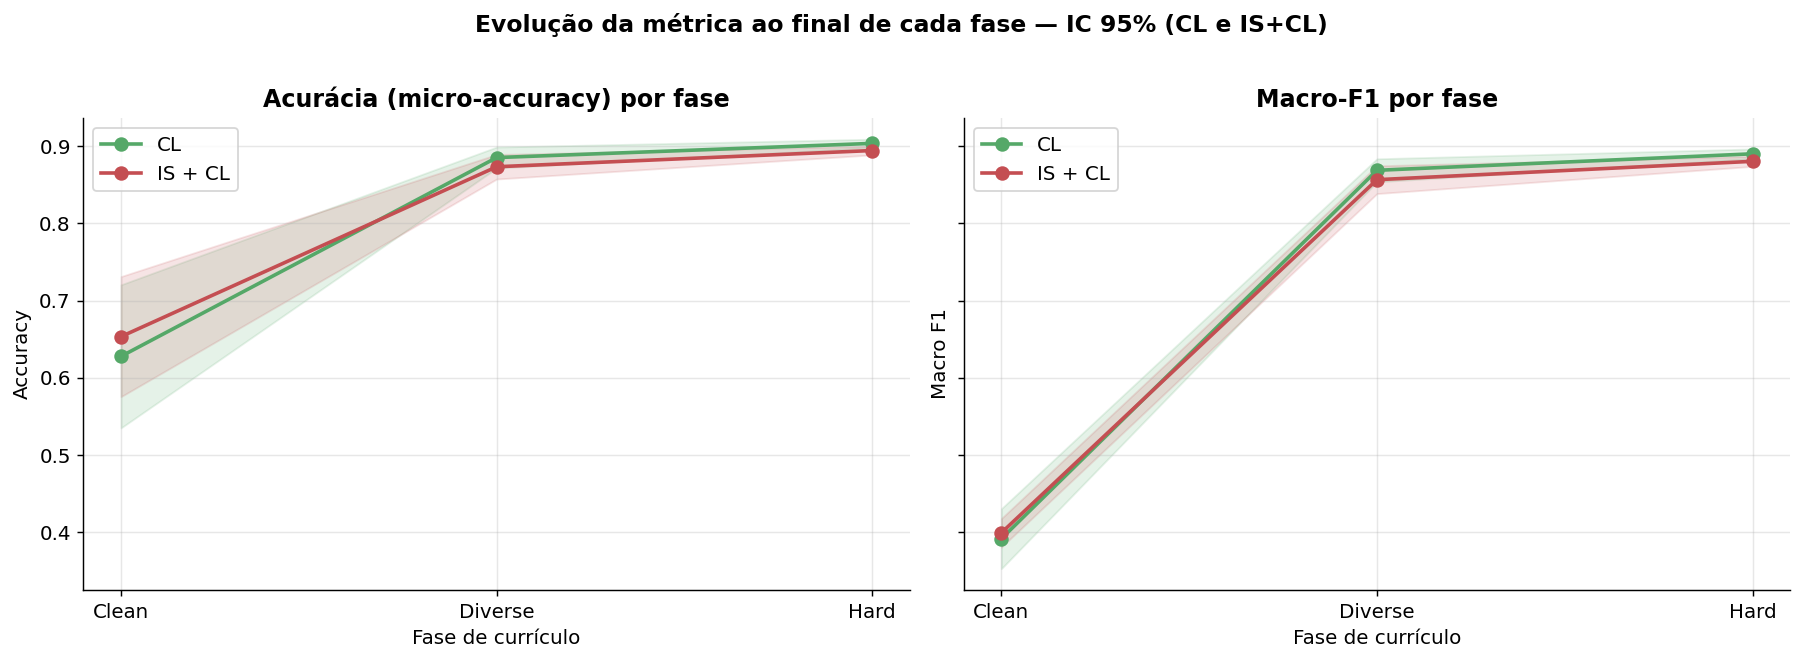

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

MODES_CURRICULUM = ('cl', 'is_cl')
CURRICULUM_PHASES = ('clean', 'diverse', 'hard')
PHASE_NAMES = {'clean': 'Clean', 'diverse': 'Diverse', 'hard': 'Hard'}

for ax, metric, title in zip(axes,
    ['accuracy', 'macro_f1'],
    ['Acurácia (micro-accuracy) por fase', 'Macro-F1 por fase']):

    for mode in MODES_CURRICULUM:
        sub = df_pm[
            (df_pm['mode'] == mode) &
            (df_pm['fold'].isin(complete_folds[mode]))
        ]
        phases_sorted = [p for p in CURRICULUM_PHASES if p in sub['phase'].unique()]
        xs, means, lows, highs = [], [], [], []
        for ph in phases_sorted:
            vals = sub[sub['phase'] == ph][metric].values
            if len(vals) < 1:
                continue
            lo, hi = ci95(vals) if len(vals) >= 2 else (vals[0], vals[0])
            xs.append(PHASE_NAMES.get(ph, ph))
            means.append(np.mean(vals))
            lows.append(lo)
            highs.append(hi)

        x_num = np.arange(len(xs))
        color = MODE_COLORS[mode]
        ax.plot(x_num, means, 'o-', label=MODE_LABELS[mode], color=color, linewidth=2, markersize=7)
        ax.fill_between(x_num, lows, highs, color=color, alpha=0.15)

    ax.set_xticks(np.arange(len(CURRICULUM_PHASES)))
    ax.set_xticklabels([PHASE_NAMES[p] for p in CURRICULUM_PHASES])
    ax.set_xlabel('Fase de currículo')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Evolução da métrica ao final de cada fase — IC 95% (CL e IS+CL)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Projeto 2² — Análise fatorial (IS × CL)

Os 4 modos formam um **delineamento fatorial 2²** com:
- Fator **A = IS** (Instance Selection): 0 = não, 1 = sim  
- Fator **B = CL** (Curriculum Learning): 0 = não, 1 = sim

| Modo | IS (A) | CL (B) |
|------|--------|--------|
| baseline | 0 | 0 |
| is | 1 | 0 |
| cl | 0 | 1 |
| is_cl | 1 | 1 |

Resposta: **acurácia** (`accuracy`) na última fase avaliada.

> Apenas os **folds completos** são utilizados por célula do delineamento.

Também na **§4.3–4.5**: mesmo delineamento com resposta **tempo total** (`total_run_time_s`).


In [11]:
# Build the 2^2 design dataframe
factor_map = {
    'baseline': (0, 0),
    'is':       (1, 0),
    'cl':       (0, 1),
    'is_cl':    (1, 1),
}

design_rows = []
for mode in MODES:
    # Use the final phase accuracy for complete folds
    sub = df_pm[
        (df_pm['mode'] == mode) &
        (df_pm['fold'].isin(complete_folds[mode]))
    ]
    # Last phase per fold
    last = (
        sub.sort_values('phase', key=lambda s: s.map(PHASE_ORDER))
        .groupby('fold')
        .last()
        .reset_index()
    )
    A, B = factor_map[mode]
    for _, row in last.iterrows():
        design_rows.append({
            'mode': mode,
            'fold': row['fold'],
            'IS':   A,
            'CL':   B,
            'accuracy': row['accuracy'],
            'micro_f1': row['micro_f1'],
            'macro_f1': row['macro_f1'],
        })

df_design = pd.DataFrame(design_rows)

# Count per cell
cell_counts = df_design.groupby('mode').size().rename('n folds completos')
print('Observações por célula do delineamento 2²:')
display(cell_counts.to_frame())

MIN_OBS = 2
cells_ok = all(v >= MIN_OBS for v in cell_counts.values)
print(f'\nTodas as células com >= {MIN_OBS} observações? {cells_ok}')

# Mesmo delineamento para tempo total de execução (timings.csv)
design_rows_time = []
for mode in MODES:
    sub_t = df_timings[
        (df_timings['mode'] == mode) &
        (df_timings['fold'].isin(complete_folds[mode]))
    ]
    A, B = factor_map[mode]
    for _, row in sub_t.iterrows():
        design_rows_time.append({
            'mode': mode,
            'fold': row['fold'],
            'IS':   A,
            'CL':   B,
            'total_run_time_s': row['total_run_time_s'],
        })

df_design_time = pd.DataFrame(design_rows_time)


Observações por célula do delineamento 2²:


,n folds completos
mode,
baseline,10
cl,10
is,10
is_cl,10



Todas as células com >= 2 observações? True


In [12]:
if not cells_ok:
    print('⚠ Não há observações suficientes em alguma célula do delineamento.')
    print('  O projeto 2² não pode ser executado com confiabilidade.')
else:
    # ---- 2^2 ANOVA — Type III SS via nested model comparison ----
    # Coding: IS, CL ∈ {-1, +1}  (sum-to-zero / effects coding)
    df_design['A']  = df_design['IS'].map({0: -1, 1: +1})
    df_design['B']  = df_design['CL'].map({0: -1, 1: +1})
    df_design['AB'] = df_design['A'] * df_design['B']

    response = 'accuracy'
    y       = df_design[response].values
    n_total = len(y)
    grand_mean = y.mean()

    from numpy.linalg import lstsq

    def fit_ss_res(X, y):
        coef, _, _, _ = lstsq(X, y, rcond=None)
        return np.sum((y - X @ coef) ** 2)

    ones = np.ones(n_total)
    A    = df_design['A'].values
    B    = df_design['B'].values
    AB   = df_design['AB'].values

    # Full model: intercept + A + B + AB
    X_full = np.column_stack([ones, A, B, AB])
    ss_res_full = fit_ss_res(X_full, y)

    # Type III SS: compare full model with model that drops each term
    ss_res_noA  = fit_ss_res(np.column_stack([ones, B, AB]), y)
    ss_res_noB  = fit_ss_res(np.column_stack([ones, A, AB]), y)
    ss_res_noAB = fit_ss_res(np.column_stack([ones, A, B]),  y)

    ss_A  = ss_res_noA  - ss_res_full   # Type III SS for IS
    ss_B  = ss_res_noB  - ss_res_full   # Type III SS for CL
    ss_AB = ss_res_noAB - ss_res_full   # Type III SS for IS×CL

    ss_tot = np.sum((y - grand_mean) ** 2)
    ss_res = ss_res_full

    # Variance explained (% of total SS)
    pct_A  = 100 * ss_A  / ss_tot
    pct_B  = 100 * ss_B  / ss_tot
    pct_AB = 100 * ss_AB / ss_tot
    pct_e  = 100 * ss_res / ss_tot

    # Cell means for effect interpretation
    cell_means = df_design.groupby(['IS', 'CL'])[response].mean()
    y00 = cell_means.get((0, 0), np.nan)
    y10 = cell_means.get((1, 0), np.nan)
    y01 = cell_means.get((0, 1), np.nan)
    y11 = cell_means.get((1, 1), np.nan)

    effect_A  = 0.5 * ((y10 - y00) + (y11 - y01))
    effect_B  = 0.5 * ((y01 - y00) + (y11 - y10))
    effect_AB = 0.5 * ((y11 - y01) - (y10 - y00))

    print('=' * 60)
    print('PROJETO 2² — Análise fatorial: IS × CL')
    print(f'Resposta: {response}  |  N = {n_total} observações totais')
    print('(SS Tipo III — comparação de modelos aninhados)')
    print('=' * 60)
    print(f'\nMédias por célula:')
    print(f'  baseline  (IS=0, CL=0): {y00:.5f}')
    print(f'  is        (IS=1, CL=0): {y10:.5f}')
    print(f'  cl        (IS=0, CL=1): {y01:.5f}')
    print(f'  is_cl     (IS=1, CL=1): {y11:.5f}')

    print(f'\nEfeitos (diferença média atribuída a cada fator):')
    print(f'  A (IS):     {effect_A:+.6f}')
    print(f'  B (CL):     {effect_B:+.6f}')
    print(f'  AB (IS×CL): {effect_AB:+.6f}')

    print(f'\nVariância explicada (SS Tipo III / SS_total):')
    print(f'  A  (IS):      {pct_A:.2f}%')
    print(f'  B  (CL):      {pct_B:.2f}%')
    print(f'  AB (IS×CL):   {pct_AB:.2f}%')
    print(f'  Erro/resíduo: {pct_e:.2f}%')

PROJETO 2² — Análise fatorial: IS × CL
Resposta: accuracy  |  N = 40 observações totais
(SS Tipo III — comparação de modelos aninhados)

Médias por célula:
  baseline  (IS=0, CL=0): 0.91128
  is        (IS=1, CL=0): 0.90760
  cl        (IS=0, CL=1): 0.90345
  is_cl     (IS=1, CL=1): 0.89421

Efeitos (diferença média atribuída a cada fator):
  A (IS):     -0.006458
  B (CL):     -0.010607
  AB (IS×CL): -0.002780

Variância explicada (SS Tipo III / SS_total):
  A  (IS):      10.54%
  B  (CL):      28.43%
  AB (IS×CL):   1.95%
  Erro/resíduo: 59.08%


### 4.1 Gráfico de efeitos principais e interação

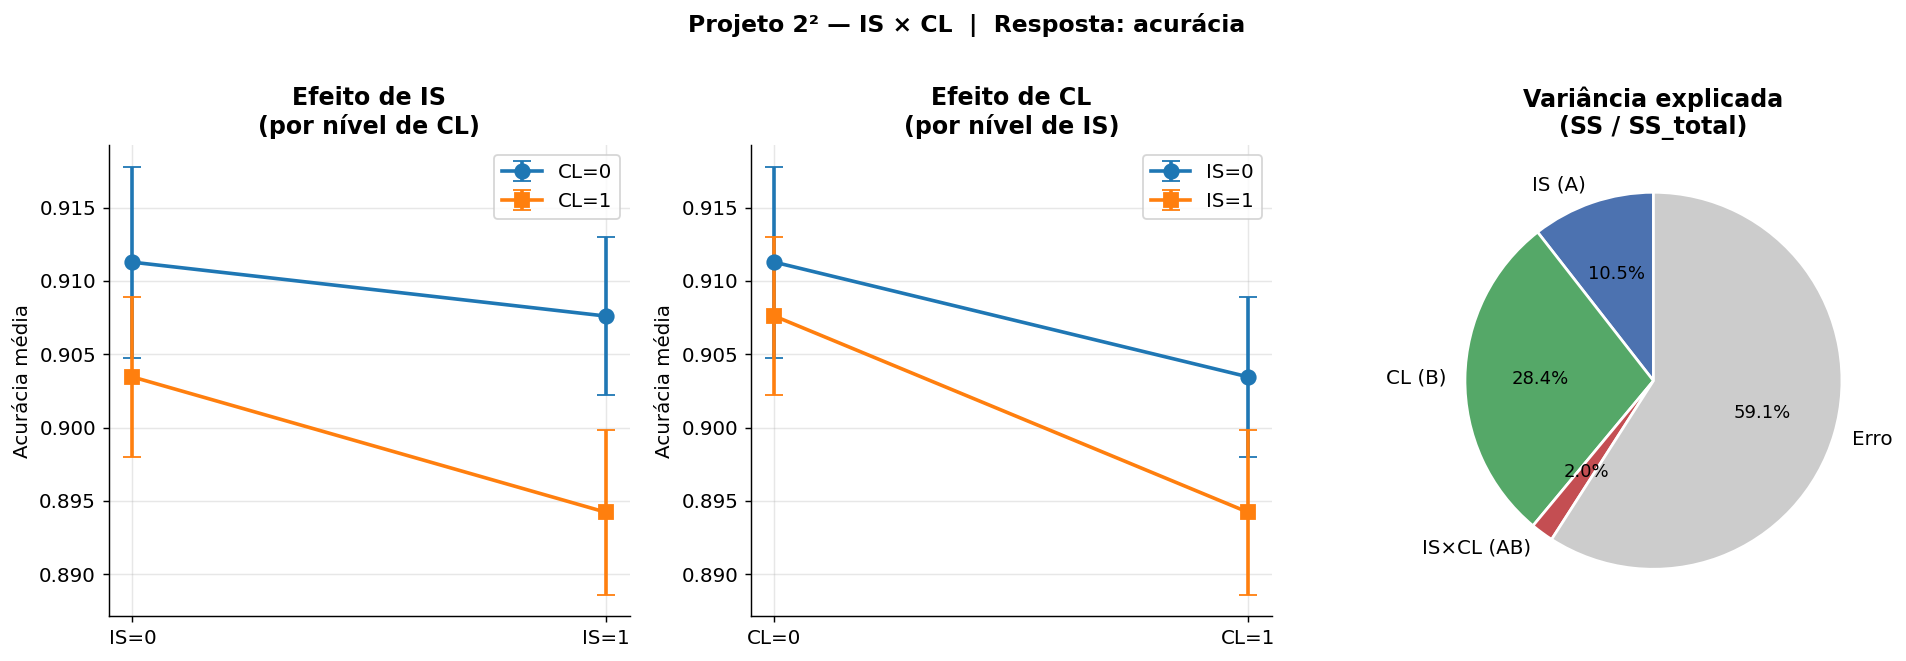

In [13]:
if cells_ok:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # --- (a) Efeito de IS ---
    ax = axes[0]
    for cl_val, ls, lbl in [(0, '-o', 'CL=0'), (1, '-s', 'CL=1')]:
        sub = df_design[df_design['CL'] == cl_val]
        grp = sub.groupby('IS')[response].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA/2, df=grp['count']-1)
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IS=0', 'IS=1'])
    ax.set_ylabel('Acurácia média')
    ax.set_title('Efeito de IS\n(por nível de CL)', fontweight='bold')
    ax.legend()

    # --- (b) Efeito de CL ---
    ax = axes[1]
    for is_val, ls, lbl in [(0, '-o', 'IS=0'), (1, '-s', 'IS=1')]:
        sub = df_design[df_design['IS'] == is_val]
        grp = sub.groupby('CL')[response].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA/2, df=grp['count']-1)
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['CL=0', 'CL=1'])
    ax.set_ylabel('Acurácia média')
    ax.set_title('Efeito de CL\n(por nível de IS)', fontweight='bold')
    ax.legend()

    # --- (c) Variância explicada (pie) ---
    ax = axes[2]
    labels_pie = ['IS (A)', 'CL (B)', 'IS×CL (AB)', 'Erro']
    sizes_pie  = [pct_A, pct_B, pct_AB, pct_e]
    colors_pie = ['#4C72B0', '#55A868', '#C44E52', '#CCCCCC']
    wedges, texts, autotexts = ax.pie(
        sizes_pie, labels=labels_pie, autopct='%1.1f%%',
        colors=colors_pie, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
    )
    for at in autotexts:
        at.set_fontsize(10)
    ax.set_title('Variância explicada\n(SS / SS_total)', fontweight='bold')

    plt.suptitle('Projeto 2² — IS × CL  |  Resposta: acurácia', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

### 4.2 Tabela ANOVA completa do projeto 2²

In [14]:
if cells_ok:
    gl_erro = n_total - 4  # 4 params: intercept, A, B, AB
    ms_e    = ss_res / gl_erro

    df_anova = pd.DataFrame([
        {'Fonte':    'A — IS',
         'SS':       ss_A,
         'GL':       1,
         'MS':       ss_A,
         'Efeito':   effect_A,
         '% var':    pct_A,
         'F':        ss_A / ms_e,
         'p-valor':  1 - stats.f.cdf(ss_A / ms_e, 1, gl_erro)},
        {'Fonte':    'B — CL',
         'SS':       ss_B,
         'GL':       1,
         'MS':       ss_B,
         'Efeito':   effect_B,
         '% var':    pct_B,
         'F':        ss_B / ms_e,
         'p-valor':  1 - stats.f.cdf(ss_B / ms_e, 1, gl_erro)},
        {'Fonte':    'AB — IS×CL',
         'SS':       ss_AB,
         'GL':       1,
         'MS':       ss_AB,
         'Efeito':   effect_AB,
         '% var':    pct_AB,
         'F':        ss_AB / ms_e,
         'p-valor':  1 - stats.f.cdf(ss_AB / ms_e, 1, gl_erro)},
        {'Fonte':    'Erro (resíduo)',
         'SS':       ss_res,
         'GL':       gl_erro,
         'MS':       ms_e,
         'Efeito':   np.nan,
         '% var':    pct_e,
         'F':        np.nan,
         'p-valor':  np.nan},
        {'Fonte':    'Total',
         'SS':       ss_tot,
         'GL':       n_total - 1,
         'MS':       np.nan,
         'Efeito':   np.nan,
         '% var':    pct_A + pct_B + pct_AB + pct_e,
         'F':        np.nan,
         'p-valor':  np.nan},
    ]).set_index('Fonte')

    print('Tabela ANOVA — Projeto 2² (SS Tipo III)\n')
    display(df_anova.round(6))

    print('\nNota: % var = SS_fator / SS_total  (variância explicada em relação à variação total).')
    print('      Como o delineamento é não-balanceado, a soma das % pode diferir de 100%.')

Tabela ANOVA — Projeto 2² (SS Tipo III)



,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,0.000417,1,0.000417,-0.006458,10.538474,6.421146,0.015771
B — CL,0.001125,1,0.001125,-0.010607,28.425524,17.319817,0.000188
AB — IS×CL,0.000077,1,0.000077,-0.002780,1.952303,1.189548,0.282667
Erro (resíduo),0.002339,36,0.000065,NaN,59.083700,NaN,NaN
Total,0.003958,39,NaN,NaN,100.000000,NaN,NaN



Nota: % var = SS_fator / SS_total  (variância explicada em relação à variação total).
      Como o delineamento é não-balanceado, a soma das % pode diferir de 100%.


### 4.3 Projeto 2² — tempo total de execução (`total_run_time_s`)

Mesmo delineamento IS × CL, mesmos folds completos que na Seção 4. A variável resposta é o **tempo total de execução** (`total_run_time_s`) por fold.

ANOVA com **SS Tipo III** (modelos aninhados), IC **95%** nos gráficos de médias.

In [15]:
if not cells_ok:
    print('⚠ Mesmo critério da Seção 4: delineamento incompleto — projeto 2² sobre tempo omitido.')
else:
    from numpy.linalg import lstsq

    def _fit_ss_res(X, y):
        coef, _, _, _ = lstsq(X, y, rcond=None)
        return np.sum((y - X @ coef) ** 2)

    dft = df_design_time.copy()
    dft['A']  = dft['IS'].map({0: -1, 1: +1})
    dft['B']  = dft['CL'].map({0: -1, 1: +1})
    dft['AB'] = dft['A'] * dft['B']

    resp_col = 'total_run_time_s'
    yt       = dft[resp_col].values
    n_t      = len(yt)
    gm       = yt.mean()

    ones_t = np.ones(n_t)
    At = dft['A'].values
    Bt = dft['B'].values
    ABt = dft['AB'].values

    X_full_t = np.column_stack([ones_t, At, Bt, ABt])
    ss_res_full_t = _fit_ss_res(X_full_t, yt)

    ss_res_noA_t  = _fit_ss_res(np.column_stack([ones_t, Bt, ABt]), yt)
    ss_res_noB_t  = _fit_ss_res(np.column_stack([ones_t, At, ABt]), yt)
    ss_res_noAB_t = _fit_ss_res(np.column_stack([ones_t, At, Bt]),  yt)

    tt_ss_A  = ss_res_noA_t  - ss_res_full_t
    tt_ss_B  = ss_res_noB_t  - ss_res_full_t
    tt_ss_AB = ss_res_noAB_t - ss_res_full_t

    tt_ss_tot = np.sum((yt - gm) ** 2)
    tt_ss_res = ss_res_full_t

    tt_pct_A  = 100 * tt_ss_A  / tt_ss_tot
    tt_pct_B  = 100 * tt_ss_B  / tt_ss_tot
    tt_pct_AB = 100 * tt_ss_AB / tt_ss_tot
    tt_pct_e  = 100 * tt_ss_res / tt_ss_tot

    cm_t = dft.groupby(['IS', 'CL'])[resp_col].mean()
    t00 = cm_t.get((0, 0), np.nan)
    t10 = cm_t.get((1, 0), np.nan)
    t01 = cm_t.get((0, 1), np.nan)
    t11 = cm_t.get((1, 1), np.nan)

    tt_effect_A  = 0.5 * ((t10 - t00) + (t11 - t01))
    tt_effect_B  = 0.5 * ((t01 - t00) + (t11 - t10))
    tt_effect_AB = 0.5 * ((t11 - t01) - (t10 - t00))

    print('=' * 60)
    print('PROJETO 2² — IS × CL  |  Resposta: tempo total (s)')
    print(f'Variável: {resp_col}  |  N = {n_t} observações')
    print('(SS Tipo III — comparação de modelos aninhados)')
    print('=' * 60)
    print('\nMédias por célula (s):')
    print(f'  baseline  (IS=0, CL=0): {t00:.2f}')
    print(f'  is        (IS=1, CL=0): {t10:.2f}')
    print(f'  cl        (IS=0, CL=1): {t01:.2f}')
    print(f'  is_cl     (IS=1, CL=1): {t11:.2f}')

    print('\nEfeitos (s):')
    print(f'  A (IS):     {tt_effect_A:+.2f}')
    print(f'  B (CL):     {tt_effect_B:+.2f}')
    print(f'  AB (IS×CL): {tt_effect_AB:+.2f}')

    print('\nVariância explicada (SS Tipo III / SS_total):')
    print(f'  A  (IS):      {tt_pct_A:.2f}%')
    print(f'  B  (CL):      {tt_pct_B:.2f}%')
    print(f'  AB (IS×CL):   {tt_pct_AB:.2f}%')
    print(f'  Erro/resíduo: {tt_pct_e:.2f}%')


PROJETO 2² — IS × CL  |  Resposta: tempo total (s)
Variável: total_run_time_s  |  N = 40 observações
(SS Tipo III — comparação de modelos aninhados)

Médias por célula (s):
  baseline  (IS=0, CL=0): 138.99
  is        (IS=1, CL=0): 92.27
  cl        (IS=0, CL=1): 55.18
  is_cl     (IS=1, CL=1): 39.71

Efeitos (s):
  A (IS):     -31.10
  B (CL):     -68.18
  AB (IS×CL): +15.63

Variância explicada (SS Tipo III / SS_total):
  A  (IS):      16.25%
  B  (CL):      78.09%
  AB (IS×CL):   4.10%
  Erro/resíduo: 1.56%


### 4.4 Gráficos — tempo total


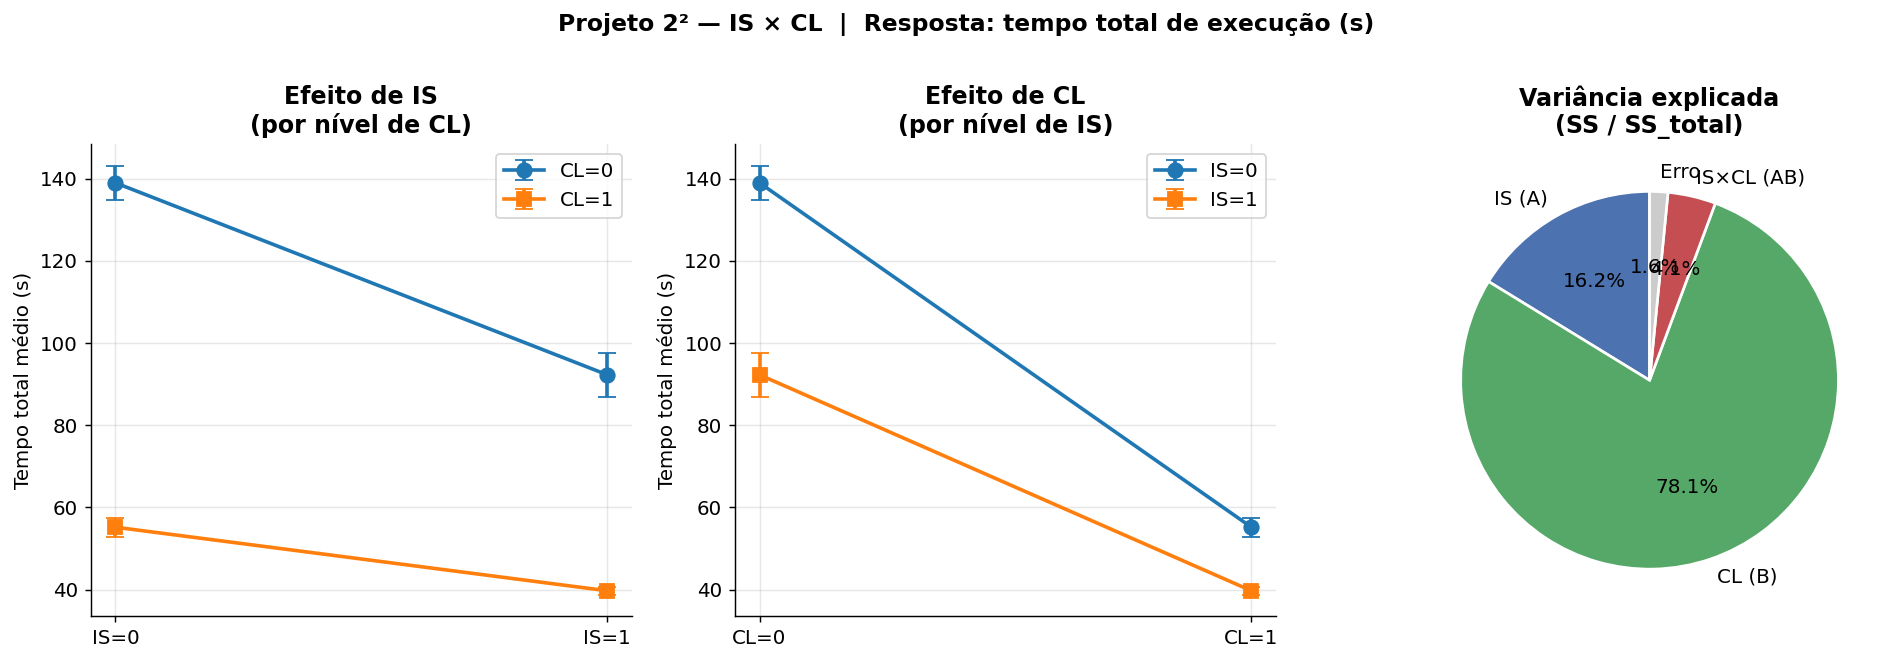

In [16]:
if cells_ok:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    resp_col = 'total_run_time_s'

    ax = axes[0]
    for cl_val, ls, lbl in [(0, '-o', 'CL=0'), (1, '-s', 'CL=1')]:
        sub = df_design_time[df_design_time['CL'] == cl_val]
        grp = sub.groupby('IS')[resp_col].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA/2, df=grp['count']-1)
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IS=0', 'IS=1'])
    ax.set_ylabel('Tempo total médio (s)')
    ax.set_title('Efeito de IS\n(por nível de CL)', fontweight='bold')
    ax.legend()

    ax = axes[1]
    for is_val, ls, lbl in [(0, '-o', 'IS=0'), (1, '-s', 'IS=1')]:
        sub = df_design_time[df_design_time['IS'] == is_val]
        grp = sub.groupby('CL')[resp_col].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA/2, df=grp['count']-1)
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['CL=0', 'CL=1'])
    ax.set_ylabel('Tempo total médio (s)')
    ax.set_title('Efeito de CL\n(por nível de IS)', fontweight='bold')
    ax.legend()

    ax = axes[2]
    labels_pie = ['IS (A)', 'CL (B)', 'IS×CL (AB)', 'Erro']
    sizes_pie  = [tt_pct_A, tt_pct_B, tt_pct_AB, tt_pct_e]
    colors_pie = ['#4C72B0', '#55A868', '#C44E52', '#CCCCCC']
    ax.pie(
        sizes_pie, labels=labels_pie, autopct='%1.1f%%',
        colors=colors_pie, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
    )
    ax.set_title('Variância explicada\n(SS / SS_total)', fontweight='bold')

    plt.suptitle('Projeto 2² — IS × CL  |  Resposta: tempo total de execução (s)', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 4.5 Tabela ANOVA — tempo total


In [17]:
if cells_ok:
    gl_t = n_t - 4
    ms_e_t = tt_ss_res / gl_t

    df_anova_time = pd.DataFrame([
        {'Fonte':    'A — IS',
         'SS':       tt_ss_A,
         'GL':       1,
         'MS':       tt_ss_A,
         'Efeito':   tt_effect_A,
         '% var':    tt_pct_A,
         'F':        tt_ss_A / ms_e_t,
         'p-valor':  1 - stats.f.cdf(tt_ss_A / ms_e_t, 1, gl_t)},
        {'Fonte':    'B — CL',
         'SS':       tt_ss_B,
         'GL':       1,
         'MS':       tt_ss_B,
         'Efeito':   tt_effect_B,
         '% var':    tt_pct_B,
         'F':        tt_ss_B / ms_e_t,
         'p-valor':  1 - stats.f.cdf(tt_ss_B / ms_e_t, 1, gl_t)},
        {'Fonte':    'AB — IS×CL',
         'SS':       tt_ss_AB,
         'GL':       1,
         'MS':       tt_ss_AB,
         'Efeito':   tt_effect_AB,
         '% var':    tt_pct_AB,
         'F':        tt_ss_AB / ms_e_t,
         'p-valor':  1 - stats.f.cdf(tt_ss_AB / ms_e_t, 1, gl_t)},
        {'Fonte':    'Erro (resíduo)',
         'SS':       tt_ss_res,
         'GL':       gl_t,
         'MS':       ms_e_t,
         'Efeito':   np.nan,
         '% var':    tt_pct_e,
         'F':        np.nan,
         'p-valor':  np.nan},
        {'Fonte':    'Total',
         'SS':       tt_ss_tot,
         'GL':       n_t - 1,
         'MS':       np.nan,
         'Efeito':   np.nan,
         '% var':    tt_pct_A + tt_pct_B + tt_pct_AB + tt_pct_e,
         'F':        np.nan,
         'p-valor':  np.nan},
    ]).set_index('Fonte')

    print('Tabela ANOVA — Projeto 2² — tempo total (SS Tipo III)\n')
    display(df_anova_time.round(6))

    print('\nNota: Efeitos em segundos; % var = SS_fator / SS_total.')


Tabela ANOVA — Projeto 2² — tempo total (SS Tipo III)



,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,9671.441008,1,9671.441008,-31.098941,16.245236,374.988976,0.0
B — CL,46491.250534,1,46491.250534,-68.184493,78.091915,1802.596574,0.0
AB — IS×CL,2442.835411,1,2442.835411,15.629573,4.103260,94.715601,0.0
Erro (resíduo),928.485632,36,25.791268,NaN,1.559589,NaN,NaN
Total,59534.012585,39,NaN,NaN,100.000000,NaN,NaN



Nota: Efeitos em segundos; % var = SS_fator / SS_total.


## 5. Resumo final consolidado (MPQA, WebKB e Reuters90)

Tabela final com os resultados essenciais por **dataset** e **modo**:
- `accuracy` (média e IC 95%)
- `macro_f1` (média e IC 95%)
- tempo médio de treino
- tempo médio de inferência

> Observação: o número de folds pode variar entre métricas e tempos quando há execuções incompletas em algum modo/fold.

In [18]:
# Resumo final consolidado (3 datasets x 4 modos)
from pathlib import Path
import numpy as np
import pandas as pd

DATASET_RUNS = {
    "mpqa": Path("results/mpqa-10cv-20260511-142747-7939ac"),
    "webkb": Path("results/webkb-10cv-20260511-162949-5c7251"),
    "reuters90": Path("results/reuters90-10cv-20260511-172123-32c5b5"),
}

MODES_ORDER = ["baseline", "is", "cl", "is_cl"]


def _extract_timing_seconds(timings_file: Path, metric_name: str) -> float | None:
    if not timings_file.exists():
        return None
    df = pd.read_csv(timings_file)
    if df.empty:
        return None
    row = df.loc[df["name"] == metric_name, "seconds"]
    if row.empty:
        return None
    return float(row.iloc[0])


rows = []
for dataset_name, run_dir in DATASET_RUNS.items():
    summary_file = run_dir / "summary.csv"
    if not summary_file.exists():
        print(f"[AVISO] summary.csv ausente em {run_dir}")
        continue

    summary = pd.read_csv(summary_file)

    for mode in MODES_ORDER:
        acc = summary[(summary["mode"] == mode) & (summary["metric"] == "accuracy")]
        f1m = summary[(summary["mode"] == mode) & (summary["metric"] == "macro_f1")]

        if acc.empty or f1m.empty:
            print(f"[AVISO] Métricas ausentes para dataset={dataset_name}, mode={mode}")
            continue

        acc = acc.iloc[0]
        f1m = f1m.iloc[0]

        train_times = []
        infer_times = []

        for fold_dir in sorted(run_dir.glob(f"{mode}_fold*")):
            train_s = _extract_timing_seconds(fold_dir / "timings.csv", "model_train_time_s")
            if train_s is not None and np.isfinite(train_s):
                train_times.append(train_s)

            pm_file = fold_dir / "phase_metrics.csv"
            if pm_file.exists():
                pm = pd.read_csv(pm_file)
                if not pm.empty and "pred_time_s" in pm.columns:
                    pred_s = float(pm.iloc[-1]["pred_time_s"])  # inferência do modelo final
                    if np.isfinite(pred_s):
                        infer_times.append(pred_s)

        rows.append(
            {
                "dataset": dataset_name,
                "mode": mode,
                "accuracy_mean": float(acc["mean"]),
                "accuracy_ci95_low": float(acc["ci_95_low"]),
                "accuracy_ci95_high": float(acc["ci_95_high"]),
                "macro_f1_mean": float(f1m["mean"]),
                "macro_f1_ci95_low": float(f1m["ci_95_low"]),
                "macro_f1_ci95_high": float(f1m["ci_95_high"]),
                "train_time_s_mean": float(np.mean(train_times)) if train_times else np.nan,
                "inference_time_s_mean": float(np.mean(infer_times)) if infer_times else np.nan,
                "n_folds_metrics": int(acc["n_folds"]),
                "n_folds_train_time": int(len(train_times)),
                "n_folds_inference_time": int(len(infer_times)),
            }
        )


df_final_summary = pd.DataFrame(rows)

if not df_final_summary.empty:
    df_final_summary["dataset"] = pd.Categorical(
        df_final_summary["dataset"], categories=list(DATASET_RUNS.keys()), ordered=True
    )
    df_final_summary["mode"] = pd.Categorical(
        df_final_summary["mode"], categories=MODES_ORDER, ordered=True
    )
    df_final_summary = df_final_summary.sort_values(["dataset", "mode"]).reset_index(drop=True)

    df_final_summary["accuracy (mean [IC95%])"] = df_final_summary.apply(
        lambda r: f"{r['accuracy_mean']:.4f} [{r['accuracy_ci95_low']:.4f}, {r['accuracy_ci95_high']:.4f}]",
        axis=1,
    )
    df_final_summary["macro_f1 (mean [IC95%])"] = df_final_summary.apply(
        lambda r: f"{r['macro_f1_mean']:.4f} [{r['macro_f1_ci95_low']:.4f}, {r['macro_f1_ci95_high']:.4f}]",
        axis=1,
    )

    df_final_summary_view = df_final_summary[
        [
            "dataset",
            "mode",
            "accuracy (mean [IC95%])",
            "macro_f1 (mean [IC95%])",
            "train_time_s_mean",
            "inference_time_s_mean",
            "n_folds_metrics",
            "n_folds_train_time",
            "n_folds_inference_time",
        ]
    ].rename(
        columns={
            "dataset": "Dataset",
            "mode": "Mode",
            "train_time_s_mean": "Training time mean (s)",
            "inference_time_s_mean": "Inference time mean (s)",
            "n_folds_metrics": "Folds (metrics)",
            "n_folds_train_time": "Folds (train time)",
            "n_folds_inference_time": "Folds (inference time)",
        }
    )

    display(df_final_summary_view)
else:
    print("Nenhum resultado consolidado foi gerado.")

,Dataset,Mode,accuracy (mean [IC95%]),macro_f1 (mean [IC95%]),Training time mean (s),Inference time mean (s),Folds (metrics),Folds (train time),Folds (inference time)
0,mpqa,baseline,"0.9113 [0.9048, 0.9178]","0.8971 [0.8895, 0.9046]",137.156636,0.443916,10,10,10
1,mpqa,is,"0.9076 [0.9022, 0.9130]","0.8932 [0.8867, 0.8996]",90.452592,0.443262,10,10,10
2,mpqa,cl,"0.9035 [0.8980, 0.9089]","0.8899 [0.8836, 0.8963]",52.078763,0.439390,10,10,10
3,mpqa,is_cl,"0.8942 [0.8886, 0.8998]","0.8802 [0.8737, 0.8867]",37.114213,0.441378,10,10,10
4,webkb,baseline,"0.8770 [0.8669, 0.8870]","0.8257 [0.8080, 0.8435]",486.592639,3.202967,10,10,10
5,webkb,is,"0.8634 [0.8538, 0.8730]","0.8151 [0.8005, 0.8296]",538.254601,4.843230,10,10,10
6,webkb,cl,"0.8455 [0.8342, 0.8567]","0.8031 [0.7850, 0.8212]",360.983566,3.885390,10,10,10
7,webkb,is_cl,"0.8153 [0.8053, 0.8254]","0.7586 [0.7467, 0.7705]",172.164700,2.876182,10,10,10
8,reuters90,baseline,"0.7477 [0.7382, 0.7573]","0.4732 [0.4620, 0.4844]",1071.024851,6.925305,8,8,8
9,reuters90,is,"0.7434 [0.7327, 0.7542]","0.4677 [0.4489, 0.4866]",629.811585,5.838938,8,8,8
